<a href="https://colab.research.google.com/github/Bkaroline/limpandodadosspotify/blob/main/limpandospotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

url_dados_spotify = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQLgqaky3kDKNl3UMvLYDQaEi4UUXVSf6foSqk5DUT_7iVP6M70OuRqk1YM9JBxW6rhnGWV0Du4J4BZ/pub?gid=638703295&single=true&output=csv"

df_spotify = pd.read_csv(url_dados_spotify)

display(df_spotify.head(3))
print("\n")
display(df_spotify[["track_name", "track_artist"]].head(10))


,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,592.0,157.969,521.0,pop,-7.777,122.0,535.0,"Lady Gaga, Bruno Mars",3,304.0,...,0,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,308.0,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,507.0,104.978,747.0,pop,-10.171,117.0,438.0,Billie Eilish,4,358.0,...,608,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.2,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,808.0,108.548,554.0,pop,-4.169,159.0,372.0,Gracie Abrams,4,368.0,...,0,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,214.0,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M


,track_name,track_artist
0,Die With A Smile,"Lady Gaga, Bruno Mars"
1,BIRDS OF A FEATHER,Billie Eilish
2,That’s So True,Gracie Abrams
3,Taste,Sabrina Carpenter
4,APT.,"ROSÉ, Bruno Mars"
5,"Good Luck, Babe!",Chappell Roan
6,Diet Pepsi,Addison Rae
7,WILDFLOWER,Billie Eilish
8,Sailor Song,Gigi Perez
9,Timeless (with Playboi Carti),"The Weeknd, Playboi Carti"


In [8]:
# identificar o operador de separação

df_spotify["artistas_separados"] = df_spotify["track_artist"].str.split(",")

#vamos explodir esses dados para mostrar individualmente
df_explodido = df_spotify.explode("artistas_separados")

# vamos limpar esse dado, para remover os espaços no começo
df_explodido["artistas_separados"] = df_explodido["artistas_separados"].str.strip()

display(df_explodido[["artistas_separados", "track_name"]].head(10))

,artistas_separados,track_name
0,Lady Gaga,Die With A Smile
0,Bruno Mars,Die With A Smile
1,Billie Eilish,BIRDS OF A FEATHER
2,Gracie Abrams,That’s So True
3,Sabrina Carpenter,Taste
4,ROSÉ,APT.
4,Bruno Mars,APT.
5,Chappell Roan,"Good Luck, Babe!"
6,Addison Rae,Diet Pepsi
7,Billie Eilish,WILDFLOWER


In [25]:
# vamos encontrar um panorama geral das popularidades das musicas

media_populariade = df_explodido['track_popularity'].mean()
print(media_populariade)

mediana_popularidade = df_explodido['track_popularity'].median()
print(mediana_popularidade)

moda_popularidade = df_explodido['track_popularity'].mode()[0]
print(moda_popularidade)

# para nossa amplitude vamos aproveitar e descobrir qual musica é mais popular e a menos popular
max_popularidade = df_explodido["track_popularity"].max()
min_popularidade = df_explodido["track_popularity"].min()
amplitude_popularidade = max_popularidade-min_popularidade
print(amplitude_popularidade)

# musica mais popular
indice_mais_popular = df_explodido["track_artist"].idxmax()
musica_mais_popular = df_explodido.loc[indice_mais_popular, "track_name"]
print(f"A música mais popular é: {musica_mais_popular}")

#musica menos popular
indice_menos_popular = df_explodido["track_artist"].idxmin()
musica_menos_popular = df_explodido.loc[indice_menos_popular, "track_name"]
print(f"A música menos popular é: {musica_menos_popular}")

75.69988276670574
74.0
70
32
A música mais popular é: 晴る
A música menos popular é: Bye Bye Bye


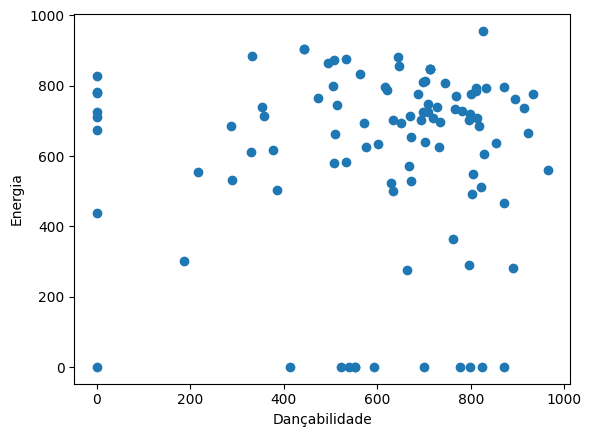

In [30]:
import matplotlib.pyplot as plt

# para criar uma amostragem, ou seja, pegar aleatoriamente
amostra = df_explodido.sample(100, random_state=42)

plt.scatter(amostra["energy"], amostra["danceability"])
plt.xlabel("Dançabilidade")
plt.ylabel("Energia")

plt.show()